# 📈 Forecasting de revenue - Hapy Cow Ice Cream


## Créditos

Este notebook está basado en el caso de estudio:

> **Caso N.° HK1207-PDF-ENG**  
> University of Hong Kong / Harvard Business Publishing Education  
> Disponible en: https://hbsp.harvard.edu/product/HK1207-PDF-ENG

El material del caso es propiedad de la University of Hong Kong y distribuido por Harvard Business Publishing. Su uso en este curso es exclusivamente con fines académicos.

---


## Contexto e introducción

En el caso de Happy Cow Ice Cream, se busca desarrollar un modelo de forecasting a partir de datos diarios de ventas por producto, con el fin de apoyar decisiones de negocio 📊. Debido al alto nivel de ruido y variabilidad en la información diaria, el análisis se enfocará en construir un forecast semanal, permitiendo identificar patrones más estables como tendencias y posibles estacionalidades 📅. No obstante, el problema presenta retos importantes, como la limitada cantidad de datos disponibles y la influencia de factores externos en la demanda, lo que hace necesario complementar el modelado con un análisis exploratorio cuidadoso 🧠.

## 🧩 Enunciado

Como consultor externo, se le solicita desarrollar un **modelo predictivo de revenue** para los productos más relevantes, generando pronósticos **semanales (cuatro semanas adelante)**. Los datos se encuentran en el archivo `ice_cream_data_daily.csv`, que incluye:

- **Product**
- **Date_clean**
- **Revenue**

El objetivo es producir pronósticos confiables que apoyen la planificación, reduzcan el desperdicio y mejoren la eficiencia operativa. 📊🤝


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error

data = pd.read_csv("ice_cream_data_daily.csv", delimiter=',', encoding="utf8")
data.head(100)



,Product,Date_clean,Revenue
0,1 Topping,2017-04-01,0.0
1,1 Topping,2017-04-02,0.0
2,1 Topping,2017-04-03,0.0
3,1 Topping,2017-04-04,0.0
4,1 Topping,2017-04-05,0.0
...,...,...,...
95,1 Topping,2017-07-05,0.0
96,1 Topping,2017-07-06,0.0
97,1 Topping,2017-07-07,0.0
98,1 Topping,2017-07-08,0.0


Esto se hizo con la finalidad de revisar si hay datos faltantes para cada hora es importante saber que todos los sabores estuvieran

# ✅ Criterios de evaluación – Descripción

1) **Exploración y limpieza de los datos**  
Realiza una exploración clara de la serie y sus variables (tendencias, estacionalidad, valores atípicos, faltantes). Limpia y estandariza formatos (fechas, unidades, precios) y deja trazabilidad de las decisiones tomadas para garantizar un conjunto de datos listo para modelar.

2) **Modelo “base”, métrica y separación temporal**  
Implementa un modelo base razonable para tu problema (p. ej., media móvil) y evalúalo con una métrica coherente con el negocio (MAE, RMSE o MAPE). Separa correctamente entrenamiento y test respetando la temporalidad, evitando cualquier fuga de información.

3) **Modelo avanzado para mejorar predicciones**  
Construye un modelo más sofisticado (ARIMA/SARIMA/SARIMAX, Prophet, ETS o un enfoque de ML con rasgos temporales/exógenas) y justifica su elección. Demuestra mejora frente al modelo base usando la misma ventana de evaluación y la misma métrica.

4) **Uso del modelo: predicción 4 semanas adelante**  
Selecciona un modelo ganador y genera un pronóstico operativo a **4 semanas** (multi‐paso). Entrega las predicciones en una tabla y un gráfico del horizonte, idealmente con intervalos de confianza y una breve guía de cómo reproducir el proceso.


### Punto 1

In [20]:
conteo_productos = (
    data["Product"]
    .astype("string")
    .str.strip()
    .value_counts(dropna=False, sort=False)
)

print(conteo_productos.to_string())

Product
1 Topping                           183
1 Topping Staff                     183
1 Toppings St                       183
3 Topping                           183
3 Topping Staff                     183
Apricot                             183
Apricot ST                          183
Apricot Staff                       183
Asia Research Free Scoop            183
Banana Caramel  /                   183
Banana Caramel St                   183
Banana Staff                        183
Building Promotion                  183
Chai Tea                            183
Chai Tea Staff                      183
Chai Tea st                         183
Cherry Alm Staff                    183
Cherry Almond                       183
Cherry Almond Fudge st              183
Chocoate Cookies                    183
Chocolate                           183
Chocolate St                        183
Chocolate Staff                     183
Coffee                              183
Coffee  St                      

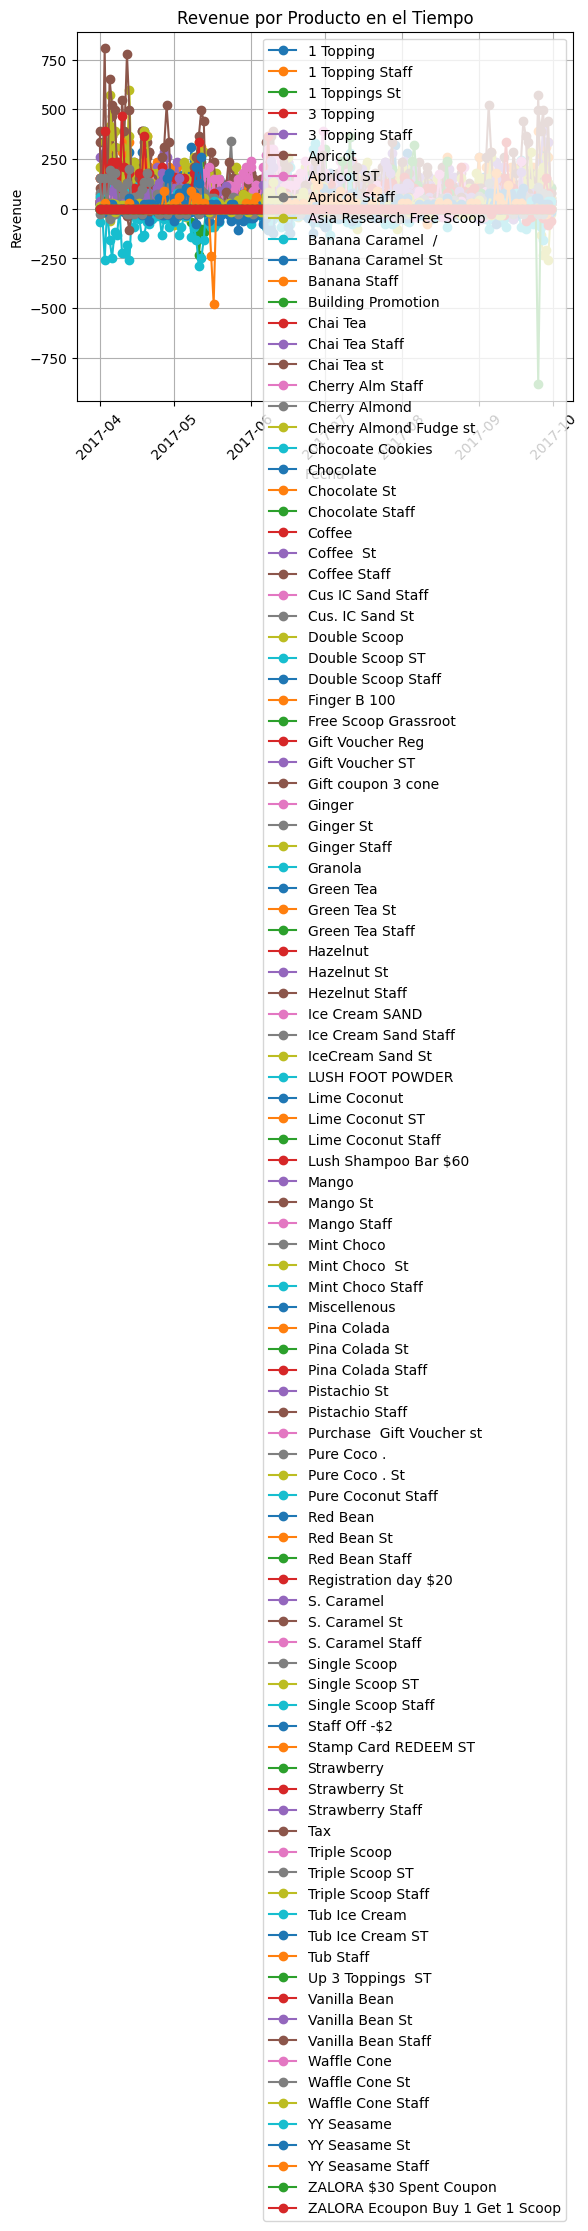

In [21]:
data["Date_clean"] = pd.to_datetime(data["Date_clean"])

for producto in data["Product"].unique():
    filtro = data[data["Product"] == producto]
    plt.plot(filtro["Date_clean"], filtro["Revenue"], marker="o", label=producto)

plt.title("Revenue por Producto en el Tiempo")
plt.xlabel("Fecha")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import re
import json
import os
import webbrowser

# =========================================================
# 1) COPIA Y LIMPIEZA INICIAL
# =========================================================
df = data.copy()

df["Date_clean"] = pd.to_datetime(df["Date_clean"], errors="coerce")
df["Product"] = df["Product"].astype(str).str.strip()
df["Revenue"] = pd.to_numeric(df["Revenue"], errors="coerce")

df = df.dropna(subset=["Date_clean", "Product", "Revenue"])

# Guardar nombre original por seguridad
df["Product_original"] = df["Product"]

# =========================================================
# 2) DICCIONARIO DE EQUIVALENCIAS
# =========================================================
EXCEPCIONES_BASE = {
    "1 topping": "1 Topping",
    "1 toppings": "1 Topping",
    "3 topping": "3 Topping",
    "3 toppings": "3 Topping",
    "banana caramel": "Banana Caramel",
    "banana": "Banana Caramel",
    "apricot": "Apricot",
    "chai tea": "Chai Tea",
    "cherry almond": "Cherry Almond",
    "cherry almond fudge": "Cherry Almond Fudge",
    "chocoate cookies": "Chocolate Cookies",
    "chocolate": "Chocolate",
    "coffee": "Coffee",
    "cus ic sand": "Cus IC Sand",
    "cus. ic sand": "Cus IC Sand",
    "double scoop": "Double Scoop",
    "green tea": "Green Tea",
    "hazelnut": "Hazelnut",
    "hezelnut": "Hazelnut",
    "ice cream sand": "Ice Cream Sand",
    "icecream sand": "Ice Cream Sand",
    "lime coconut": "Lime Coconut",
    "mango": "Mango",
    "mint choco": "Mint Choco",
    "miscellenous": "Miscellenous",
    "pina colada": "Pina Colada",
    "pistachio": "Pistachio",
    "pure coco": "Pure Coconut",
    "pure coconut": "Pure Coconut",
    "red bean": "Red Bean",
    "s. caramel": "S. Caramel",
    "single scoop": "Single Scoop",
    "strawberry": "Strawberry",
    "triple scoop": "Triple Scoop",
    "tub": "Tub Ice Cream",
    "tub ice cream": "Tub Ice Cream",
    "up 3 toppings": "Up 3 Toppings",
    "vanilla bean": "Vanilla Bean",
    "waffle cone": "Waffle Cone",
    "yy seasame": "YY Seasame"
}

# =========================================================
# 3) FUNCIÓN PARA LIMPIAR Y CLASIFICAR PRODUCTOS
# =========================================================
def limpiar_producto(prod):
    s = str(prod).strip()

    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"\s*/\s*$", "", s)
    s = re.sub(r"\s*\.\s*$", "", s)

    if re.search(r"\bstaff$", s, flags=re.IGNORECASE):
        categoria = "Staff"
        base = re.sub(r"\bstaff$", "", s, flags=re.IGNORECASE).strip()

    elif re.search(r"\bst$", s, flags=re.IGNORECASE):
        categoria = "Student"
        base = re.sub(r"\bst$", "", s, flags=re.IGNORECASE).strip()

    else:
        categoria = "Publico general"
        base = s.strip()

    base = re.sub(r"\s+", " ", base)
    base = re.sub(r"\s*/\s*$", "", base)
    base = re.sub(r"\s*\.\s*$", "", base).strip()

    clave = base.lower()
    base_final = EXCEPCIONES_BASE.get(clave, base)

    producto_mostrado = f"{base_final} - {categoria}"

    return pd.Series([base_final, categoria, producto_mostrado])

df[["Product_base", "Categoria", "Product_limpio"]] = df["Product"].apply(limpiar_producto)
df["Product"] = df["Product_limpio"]

# =========================================================
# 4) AGRUPAR REVENUE YA LIMPIO
# =========================================================
df_grouped = (
    df.groupby(["Date_clean", "Product_base", "Categoria"], as_index=False)["Revenue"]
    .sum()
    .sort_values(["Product_base", "Categoria", "Date_clean"])
)

# =========================================================
# 5) TOTAL POR SABOR (suma Staff + Student + Publico general)
# =========================================================
df_total_sabor = (
    df_grouped.groupby(["Date_clean", "Product_base"], as_index=False)["Revenue"]
    .sum()
    .sort_values(["Product_base", "Date_clean"])
)
df_total_sabor["Categoria"] = "Total categoria"

# =========================================================
# 6) TOTAL GENERAL DE TODO
# =========================================================
df_total_general = (
    df_grouped.groupby(["Date_clean"], as_index=False)["Revenue"]
    .sum()
    .sort_values("Date_clean")
)

# =========================================================
# 7) CREAR TRAZAS
# =========================================================
sabores = sorted(df_grouped["Product_base"].unique())
categorias_base = ["Publico general", "Student", "Staff"]

fig = go.Figure()
trace_map = {}

for idx, sabor in enumerate(sabores):
    trace_map[sabor] = {}

    # Categorías base
    for categoria in categorias_base:
        temp = df_grouped[
            (df_grouped["Product_base"] == sabor) &
            (df_grouped["Categoria"] == categoria)
        ].sort_values("Date_clean")

        fig.add_trace(
            go.Scatter(
                x=temp["Date_clean"],
                y=temp["Revenue"],
                mode="lines+markers",
                name=categoria,
                visible=(idx == 0)
            )
        )
        trace_map[sabor][categoria] = len(fig.data) - 1

    # Total por sabor
    temp_total = df_total_sabor[
        df_total_sabor["Product_base"] == sabor
    ].sort_values("Date_clean")

    fig.add_trace(
        go.Scatter(
            x=temp_total["Date_clean"],
            y=temp_total["Revenue"],
            mode="lines+markers",
            name="Total categoria",
            visible=False,
            line=dict(dash="dash")
        )
    )
    trace_map[sabor]["Total categoria"] = len(fig.data) - 1

# Traza final: total general
fig.add_trace(
    go.Scatter(
        x=df_total_general["Date_clean"],
        y=df_total_general["Revenue"],
        mode="lines+markers",
        name="Total general",
        visible=False,
        line=dict(width=4)
    )
)
global_trace_index = len(fig.data) - 1

# =========================================================
# 8) DISEÑO BASE
# =========================================================
titulo_inicial = f"Revenue de {sabores[0]} por categoría" if sabores else "Revenue por categoría"

fig.update_layout(
    title=titulo_inicial,
    xaxis_title="Fecha",
    yaxis_title="Revenue",
    template="plotly_white",
    hovermode="x unified",
    width=1450,
    height=850,
    margin=dict(t=120, r=40, l=60, b=60),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="left",
        x=0
    )
)

# =========================================================
# 9) EXPORTAR A HTML
# =========================================================
grafico_html = pio.to_html(
    fig,
    full_html=False,
    include_plotlyjs="cdn",
    div_id="grafico_sabores"
)

options_html = "\n".join(
    [f'<option value="{sabor}">{sabor}</option>' for sabor in sabores]
)

html_final = f"""
<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="utf-8">
    <title>Gráfico de sabores</title>
    <style>
        body {{
            font-family: Arial, sans-serif;
            margin: 20px;
        }}
        .barra-controles {{
            display: flex;
            gap: 12px;
            align-items: center;
            flex-wrap: wrap;
            margin-bottom: 16px;
        }}
        .barra-controles label {{
            font-weight: bold;
        }}
        .barra-controles select,
        .barra-controles button {{
            padding: 8px 12px;
            font-size: 14px;
            cursor: pointer;
        }}
    </style>
</head>
<body>

<div class="barra-controles">
    <label for="selectorSabor">Sabor:</label>
    <select id="selectorSabor">
        {options_html}
    </select>

    <button id="btnTotalCategoria">Mostrar total categoría</button>
    <button id="btnTotalGeneral">Mostrar total general</button>
</div>

{grafico_html}

<script>
    const sabores = {json.dumps(sabores, ensure_ascii=False)};
    const traceMap = {json.dumps(trace_map, ensure_ascii=False)};
    const globalTraceIndex = {global_trace_index};

    const gd = document.getElementById("grafico_sabores");
    const selector = document.getElementById("selectorSabor");
    const btnTotalCategoria = document.getElementById("btnTotalCategoria");
    const btnTotalGeneral = document.getElementById("btnTotalGeneral");

    let saborActual = sabores.length > 0 ? sabores[0] : null;
    let totalCategoriaVisible = false;
    let vistaTotalGeneral = false;

    function actualizarVista() {{
        const visibles = Array(gd.data.length).fill(false);

        if (vistaTotalGeneral) {{
            visibles[globalTraceIndex] = true;
            Plotly.restyle(gd, "visible", visibles);
            Plotly.relayout(gd, {{
                title: "Revenue total general (suma de todas las categorías)"
            }});

            selector.disabled = true;
            btnTotalCategoria.disabled = true;
            btnTotalGeneral.textContent = "Volver al detalle";
            return;
        }}

        visibles[traceMap[saborActual]["Publico general"]] = true;
        visibles[traceMap[saborActual]["Student"]] = true;
        visibles[traceMap[saborActual]["Staff"]] = true;

        if (totalCategoriaVisible) {{
            visibles[traceMap[saborActual]["Total categoria"]] = true;
        }}

        Plotly.restyle(gd, "visible", visibles);

        Plotly.relayout(gd, {{
            title: totalCategoriaVisible
                ? `Revenue de ${{saborActual}} por categoría + total`
                : `Revenue de ${{saborActual}} por categoría`
        }});

        selector.disabled = false;
        btnTotalCategoria.disabled = false;
        btnTotalCategoria.textContent = totalCategoriaVisible
            ? "Ocultar total categoría"
            : "Mostrar total categoría";
        btnTotalGeneral.textContent = "Mostrar total general";
    }}

    selector.addEventListener("change", function() {{
        saborActual = this.value;
        vistaTotalGeneral = false;
        actualizarVista();
    }});

    btnTotalCategoria.addEventListener("click", function() {{
        if (vistaTotalGeneral) return;
        totalCategoriaVisible = !totalCategoriaVisible;
        actualizarVista();
    }});

    btnTotalGeneral.addEventListener("click", function() {{
        vistaTotalGeneral = !vistaTotalGeneral;
        actualizarVista();
    }});

    actualizarVista();
</script>

</body>
</html>
"""

# Guardar en la misma carpeta
nombre_archivo = "grafico_sabores.html"
with open(nombre_archivo, "w", encoding="utf-8") as f:
    f.write(html_final)

print(f"Archivo generado: {nombre_archivo}")

# Abrir el archivo local correctamente en el navegador
webbrowser.open("file://" + os.path.abspath(nombre_archivo))

Archivo generado: grafico_sabores.html


True

## Hallazgos observados

* No tiene sentido que **One Scoop**, **Dolce Scoop** y **Triple Scoop** aparezcan como **valores módulo**, porque eso invierte los datos a positivos y puede distorsionar el análisis.

* En **Stamp Card * se observan **pérdidas**.

* **Ice Cream Sand** presenta **valores nulos** desde el **3 de junio** hasta el **25 de junio**.

* **Avellana** muestra una **caída** desde el **20 de mayo** hasta el **13 de junio**.

* **Jengibre**, como se mencionaba en el texto por las creencias chinas, **sube** desde el **13 de mayo** hasta el **31 de mayo**; luego **vuelve a caer**; y entre el **12 de julio** y el **9 de agosto** **presenta otro incremento**.

* **Red Bean** tiene un **comportamiento similar al de productos calientes**, ya que entre el **30 de mayo** y el **21 de junio** se comporta de esa manera.

* **Pistacho** **sube** desde el **5 de junio** hasta el **10 de junio**.

* **Lime Coconut** **sube** desde el **10 de julio** hasta el **29 de julio**; allí presenta una **leve caída**; luego **vuelve a subir** el **10 de agosto**; alcanza su **pico el 19 de agosto**; y después **desciende** hasta el **28 de agosto**.

* **Coffee** **sube** desde el **8 de junio** hasta el **27 de junio** y presenta **valores nulos** desde el **27 de junio** hasta el **6 de julio**.



### Punto 2

### ✅ Identificación Modelo Base
Primero identificamos los productos que mas se venden por categoria (estudiante, staff y tourist)


In [ ]:
def categorizar(producto):
    p = str(producto).strip()
    if p.endswith('Staff'):         
        return 'Staff'
    elif p.endswith(' St') or p.endswith(' ST'):   
        return 'Student'
    else:
        return 'Tourists'

data['Categoria'] = data['Product'].apply(categorizar)

# Top 3 por categoría
top3_categoria = (data
    .groupby(['Categoria', 'Product'])['Revenue']
    .sum()
    .reset_index()
    .sort_values(['Categoria', 'Revenue'], ascending=[True, False])
    .groupby('Categoria')
    .head(3)
)

print(top3_categoria.to_string(index=False))

Categoria                Product     Revenue
    Staff       S. Caramel Staff 10226.21211
    Staff            Mango Staff  8030.09090
    Staff        Chocolate Staff  6863.87878
  Student          S. Caramel St 25201.79338
  Student         Mint Choco  St 14861.04761
  Student               Mango St 14128.30953
 Tourists            Chai Tea st  9952.83333
 Tourists Cherry Almond Fudge st  4570.99999
 Tourists                  Mango  4310.83334


Como podemos identificar en la salida, tenemos que los sabores de helado más comprados por cada uno son:

**Staff**
- Caramel 
- Mango

**Student**
- Caramel
- Menta Chocolate
- Mango 

**Tourists**
- Chai Tea
- Cherry Almond Fudge
- Mango

### 📊 Visualización de Datos


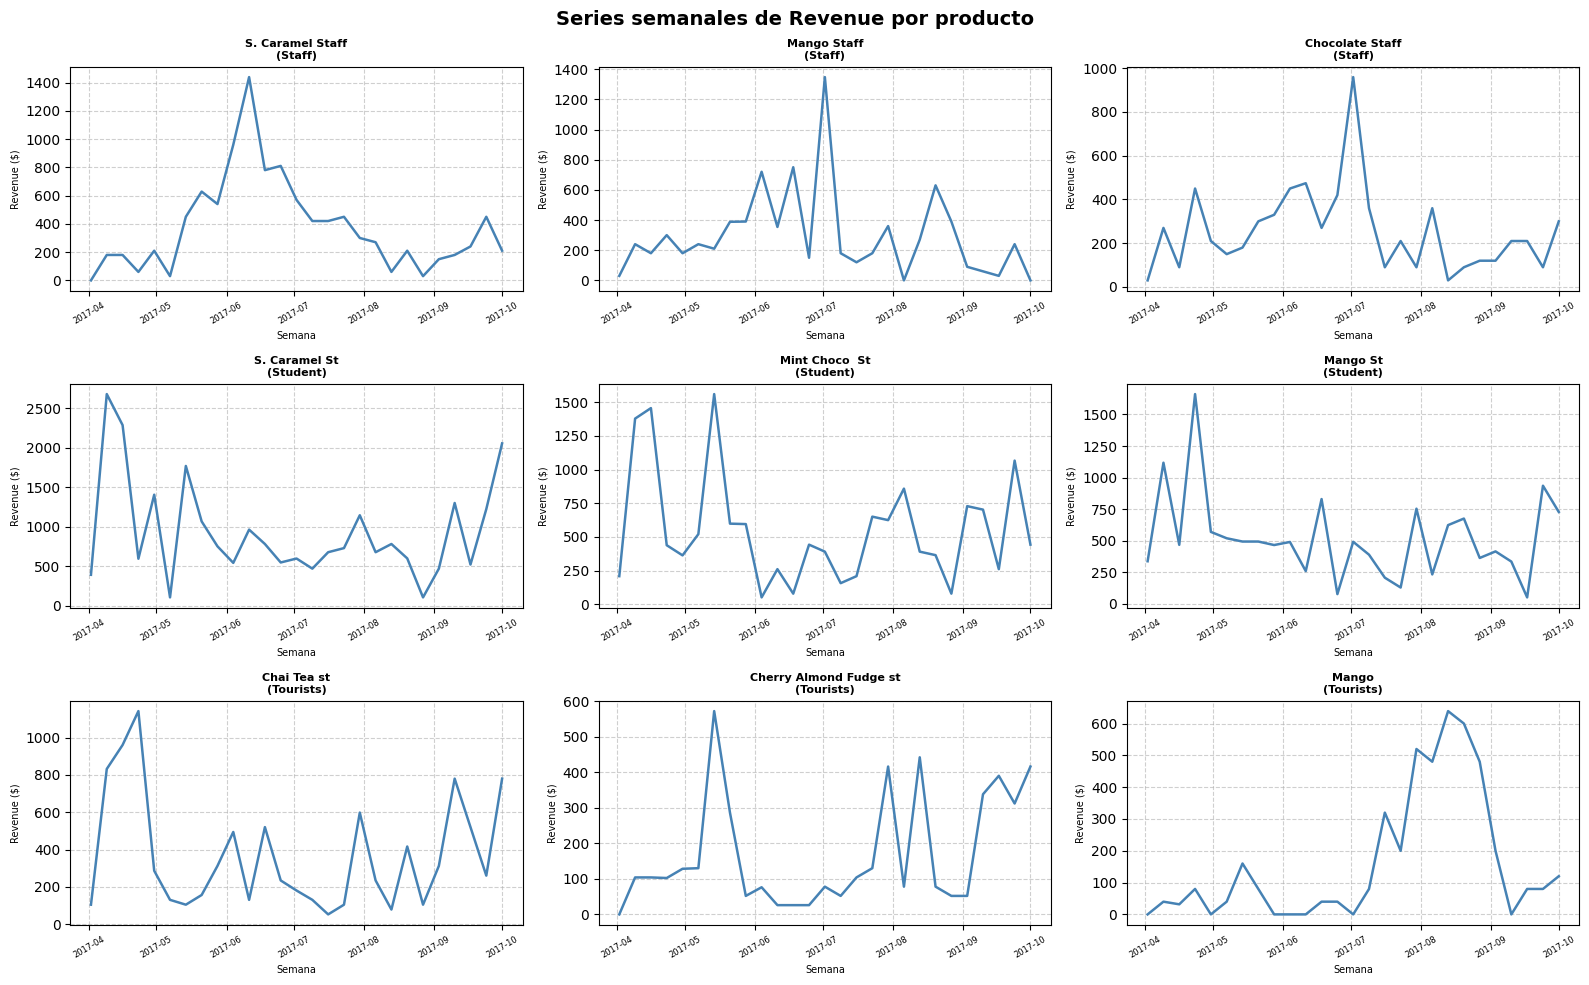

In [24]:
# aca definimos los productos que ya vimos en el punto pasado (los mas relevantes)
data['Date_clean'] = pd.to_datetime(data['Date_clean'])
productos = {
    'Staff':    ['S. Caramel Staff', 'Mango Staff', 'Chocolate Staff'],
    'Student':  ['S. Caramel St',    'Mint Choco  St', 'Mango St'],
    'Tourists': ['Chai Tea st',      'Cherry Almond Fudge st', 'Mango'],
}

def weekly_series(producto):
    sub = data[data['Product'] == producto].copy()
    sub = sub[sub['Date_clean'] <= '2017-09-30']
    serie = sub.resample('W-SUN', on='Date_clean')['Revenue'].sum().fillna(0) #usamos el W-SUN que lo hace es que agrupa semanas con inicio del domingo 
    return serie

#  graficar las 9 series semanales 
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
fig.suptitle('Series semanales de Revenue por producto', fontsize=14, fontweight='bold')

for row_idx, (categoria, prods) in enumerate(productos.items()):
    for col_idx, prod in enumerate(prods):
        ax = axes[row_idx][col_idx]
        serie = weekly_series(prod)

        ax.plot(serie.index, serie.values, color='steelblue', linewidth=1.8)
        ax.set_title(f'{prod}\n({categoria})', fontsize=8, fontweight='bold')
        ax.set_xlabel('Semana', fontsize=7)
        ax.set_ylabel('Revenue ($)', fontsize=7)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.tick_params(axis='x', labelsize=6, rotation=30)

plt.tight_layout()
plt.show()


Las series que muestran el revenue semanal de los 9 productos más relevantes en cuanto a ganancias para **Happy Cow Ice Cream** entre abril y septiembre de 2017. En general, todas muestran una alta variabilidad a lo largo de las semanas sin algun tipo de tendencia o estacionalidad clara. Tenemos tres categorias que son:

- **Staff**: Son las series más estables, con revenues semanales que rara vez sobrepasan los $600, el S. Caramel es el de mayor volumen, con picos notables en junio - julio que es cuando hay examenes

- **Student**: Este de acá es aquel que tiene mayor revenue con picos de hasta casi $2.550 semanales, las caidas más notorias son en mayo y agosto esto se puede deber a ...

- **Tourist**: Tiene el comportamiento más irregular ya que tienes picos altos y bajos poco predecibles, por ejemplo, el Cherry Almond Fudge y Mango tienen picos de caida, lo que nos puede decir un cambio no tan predecible y que puede estar ligado al flujo impredecible de visitantes

### 📈 Division train / test

In [ ]:
# Consolidamos los productos más relevantes en un solo DataFrame
df_eval = pd.DataFrame()
for categoria, prods in productos.items():
    for p in prods:
        df_eval[p] = weekly_series(p)

# Definición de la ventana de evaluación (4 semanas para el test)
n_test = 4
train = df_eval.iloc[:-n_test]
test = df_eval.iloc[-n_test:]

# Modelo Base:
forecast_values = train.iloc[-4:].mean()

print("Total:", len(df_eval),"semanas")
print("Train:", len(train), "semanas")
print("Test:", len(test), "semanas")

Total: 27 semanas
Train: 23 semanas
Test: 4 semanas


### 📈 Predicciones 

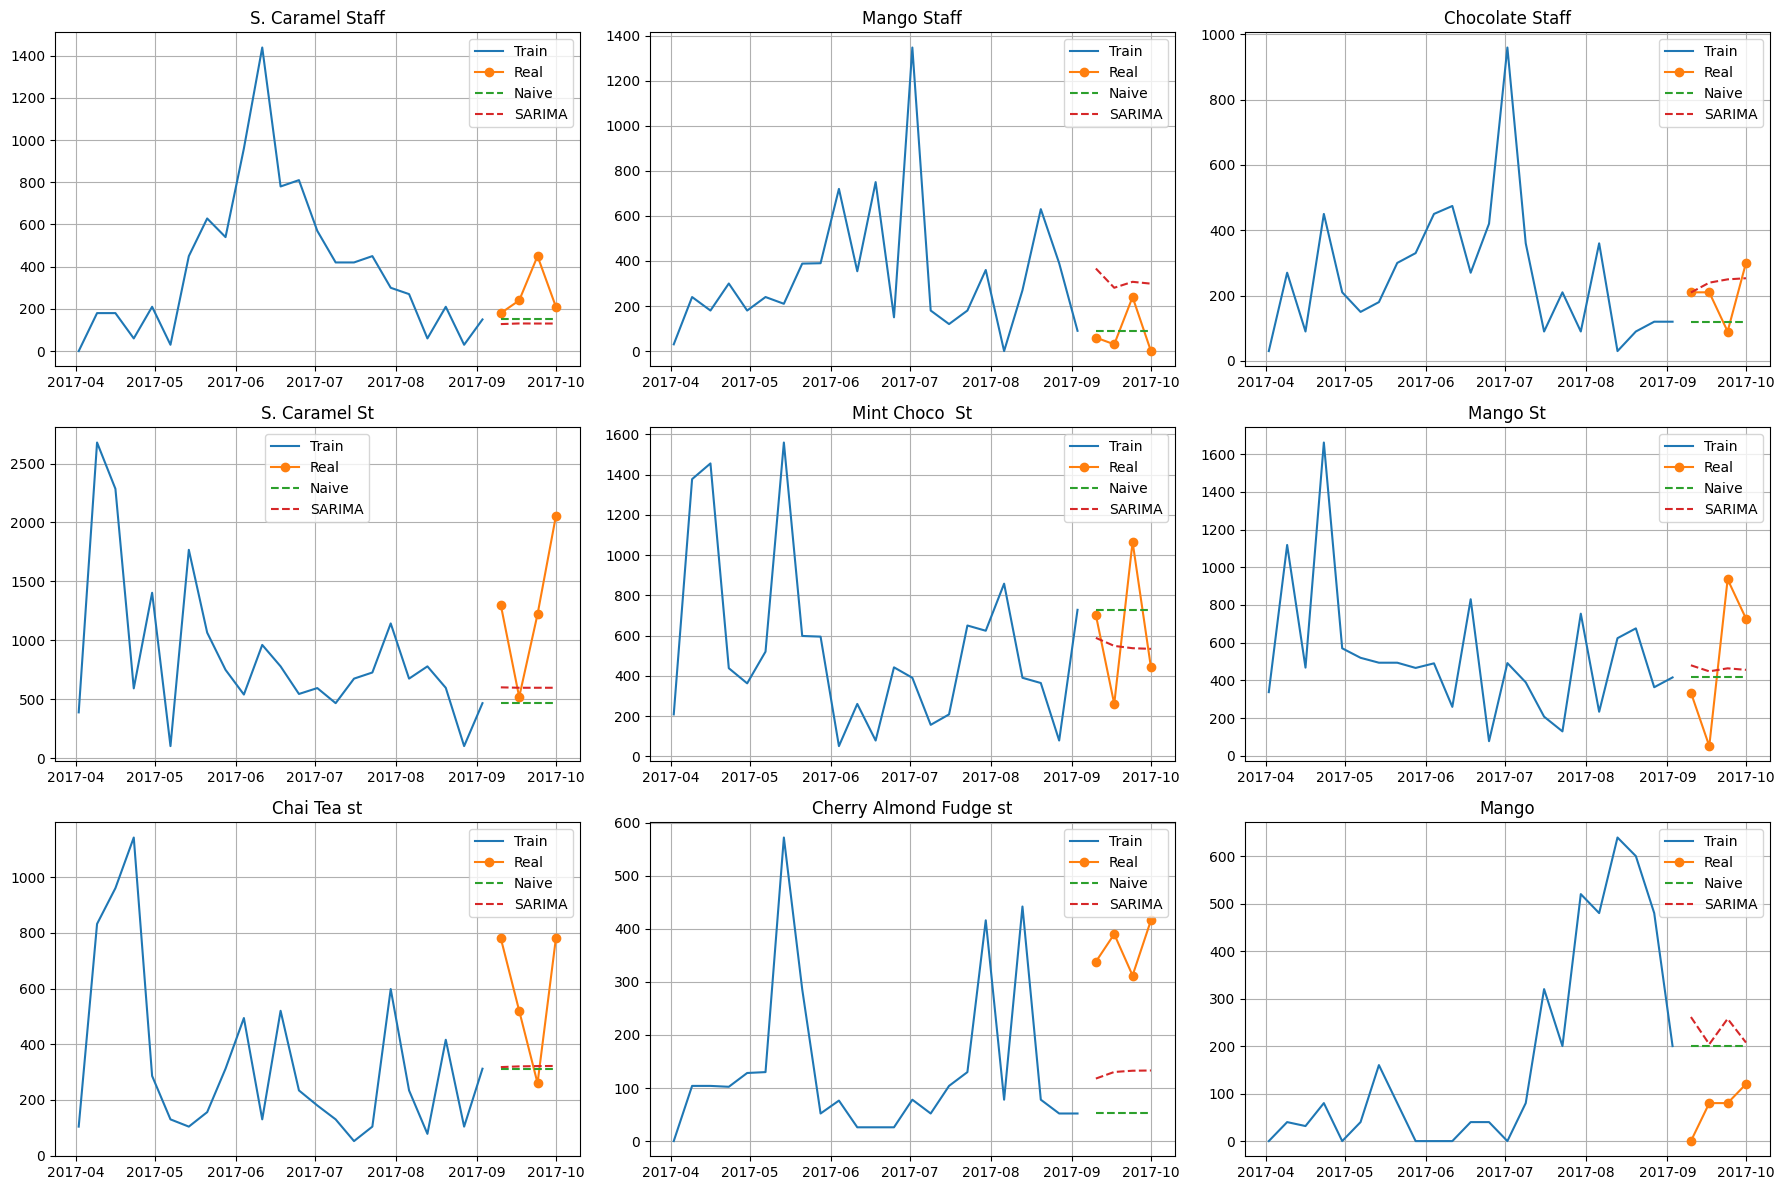

,MAE Naive,MAE SARIMA,Ganador
Producto,,,
S. Caramel Staff,120.00,139.99,Naive
Mango Staff,82.50,231.12,Naive
Chocolate Staff,97.50,59.17,SARIMA
S. Caramel St,805.79,713.57,SARIMA
Mint Choco St,279.50,255.70,SARIMA
Mango St,319.12,321.13,Naive
Chai Tea st,299.00,295.35,SARIMA
Cherry Almond Fudge st,312.00,235.58,SARIMA
Mango,130.00,162.56,Naive


In [26]:
# Primero vamos a probar con el modelo de forecast Naive
all_products = [p for prods in productos.values() for p in prods]
naive_forecasts = {}

for p in all_products:
    last_value = train[p].iloc[-1]
    pred = [last_value]*len(test)
    
    naive_forecasts[p] = pd.Series(pred, index=test.index)


# Ahora vamos con el modelo de forecast SARIMA
sarima_forecasts = {}

for p in all_products:
    try:
        model = SARIMAX(train[p], order=(1,1,1))
        results = model.fit(disp=False)
        
        pred = results.forecast(steps=len(test))
        pred.index = test.index
        
        sarima_forecasts[p] = pred
        
    except:
        print(f"Error en {p}")

# graficas 
# graficas 
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, p in enumerate(all_products):
    ax = axes[i]
    
    ax.plot(train.index, train[p], label='Train')
    ax.plot(test.index, test[p], label='Real', marker='o')
    
    ax.plot(test.index, naive_forecasts[p], 
             label='Naive', linestyle='--')
    
    ax.plot(test.index, sarima_forecasts[p], 
             label='SARIMA', linestyle='--')
    
    ax.set_title(p)
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.show()

# metricas de ambos modelos
resultados = []
for p in all_products:
    mae_naive  = mean_absolute_error(test[p], naive_forecasts[p])
    mae_sarima = mean_absolute_error(test[p], sarima_forecasts[p])
    resultados.append({
        'Producto':   p,
        'MAE Naive':  round(mae_naive, 2),
        'MAE SARIMA': round(mae_sarima, 2),
        'Ganador':    'SARIMA' if mae_sarima < mae_naive else 'Naive'
    })

pd.DataFrame(resultados).set_index('Producto')




### 📈 Analisis de una serie 
En esta sección lo que haremos sera analizar la serie de tiempo del producto más significativo

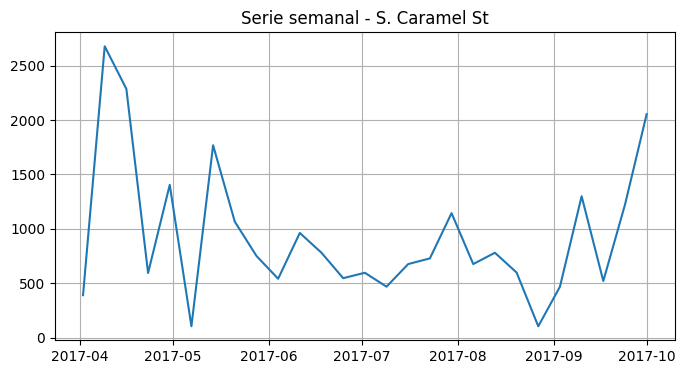

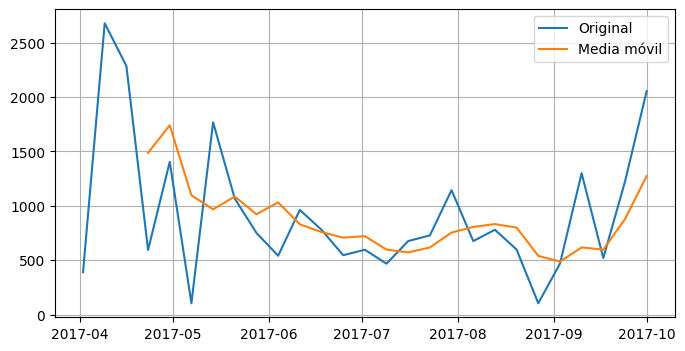

In [39]:
serie_analizar = df_eval['S. Caramel St']

plt.figure(figsize=(8,4))
plt.plot(serie_analizar)
plt.title("Serie semanal - S. Caramel St")
plt.grid()
plt.show()

# tendencia
plt.figure(figsize=(8,4))
plt.plot(serie_analizar, label='Original')
plt.plot(serie_analizar.rolling(4).mean(), label='Media móvil')
plt.legend()
plt.grid()
plt.show()

### Punto 3

In [ ]:
# =========================
# PUNTO 3 - HIERARCHICAL FORECAST CON NIXTLA
# =========================

# Install required libraries
!pip install statsforecast hierarchicalforecast

import pandas as pd
import inspect
import warnings
warnings.filterwarnings("ignore")

import statsforecast
import hierarchicalforecast
from hierarchicalforecast.utils import aggregate
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from hierarchicalforecast.core import HierarchicalReconciliation
from hierarchicalforecast.methods import BottomUp, MinTrace

print("statsforecast:", statsforecast.__version__)
print("hierarchicalforecast:", hierarchicalforecast.__version__)

# --- 1. PREPARAR df_hier ---
# Asegúrate de tener df_grouped del Punto 1
df_hier = df_grouped.copy()
df_hier["Total"] = "Total"
df_hier = df_hier.rename(columns={"Date_clean": "ds", "Revenue": "y"})[
    ["ds", "Total", "Product_base", "Categoria", "y"]
]
df_hier = df_hier.sort_values(["Total", "Product_base", "Categoria", "ds"]).reset_index(drop=True)

# Limpiar strings (sin espacios dobles ni slashes)
for col in ["Total", "Product_base", "Categoria"]:
    df_hier[col] = (
        df_hier[col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.replace("/", "-", regex=False)
    )

# --- 2. AGREGAR JERARQUÍA ---
spec = [
    ["Total"],
    ["Total", "Product_base"],
    ["Total", "Product_base", "Categoria"]
]

Y_df, S_df, tags = aggregate(df=df_hier, spec=spec)
# The line Y_df = Y_df.reset_index() was removed here because it was creating an unwanted 'index' column.
Y_df["ds"] = pd.to_datetime(Y_df["ds"])
Y_df["y"] = pd.to_numeric(Y_df["y"], errors="coerce").fillna(0.0)
Y_df = Y_df.sort_values(["unique_id", "ds"]).reset_index(drop=True)

print(f"Series en jerarquía: {Y_df['unique_id'].nunique()}")
print(Y_df.head())

# --- 3. FORECAST BASE ---
h = 28  # 4 semanas

sf = StatsForecast(
    models=[AutoARIMA(season_length=7)],
    freq="D",
    n_jobs=1
)
Y_hat_df = sf.forecast(df=Y_df, h=h)
print("Forecast generado:", Y_hat_df.shape)

# --- 4. RECONCILIACIÓN JERÁRQUICA ---
hrec = HierarchicalReconciliation(
    reconcilers=[BottomUp(), MinTrace(method="ols")]
)

# Compatibilidad con distintas versiones de hierarchicalforecast
reconcile_sig = inspect.signature(hrec.reconcile)
if "S_df" in reconcile_sig.parameters:
    fcst_rec = hrec.reconcile(Y_hat_df=Y_hat_df, Y_df=Y_df, S_df=S_df, tags=tags)
else:
    fcst_rec = hrec.reconcile(Y_hat_df=Y_hat_df, Y_df=Y_df, S=S_df, tags=tags)

print("Reconciliación OK. Shape:", fcst_rec.shape)
fcst_rec.head(20)

In [ ]:
# =========================
# GRÁFICAS CON INTERVALOS DE CONFIANZA
# =========================

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from hierarchicalforecast.core import HierarchicalReconciliation
from hierarchicalforecast.methods import BottomUp, MinTrace
from statsforecast.utils import ConformalIntervals
import inspect

# --- RE-GENERAR FORECAST CON INTERVALOS ---
sf = StatsForecast(
    models=[AutoARIMA(season_length=7)],
    freq="D",
    n_jobs=1
)

# Ensure no 'index' column remains that StatsForecast might interpret as an exogenous feature
if 'index' in Y_df.columns:
    Y_df = Y_df.drop(columns=['index'])

# prediction_intervals usa conformal calibration (no requiere distribución)
Y_hat_df = sf.forecast(
    df=Y_df,
    h=28,
    prediction_intervals=ConformalIntervals(h=28, n_windows=2),
    level=[80, 95]   # intervalos al 80% y 95%
)

print("Columnas Y_hat_df:", Y_hat_df.columns.tolist())

# --- RECONCILIACIÓN ---
hrec = HierarchicalReconciliation(reconcilers=[BottomUp(), MinTrace(method="ols")])
sig  = inspect.signature(hrec.reconcile)

if "S_df" in sig.parameters:
    fcst_rec = hrec.reconcile(
        Y_hat_df=Y_hat_df, Y_df=Y_df, S_df=S_df, tags=tags,
        level=[80, 95]
    )
else:
    fcst_rec = hrec.reconcile(
        Y_hat_df=Y_hat_df, Y_df=Y_df, S=S_df, tags=tags,
        level=[80, 95]
    )

print("Columnas fcst_rec:", fcst_rec.columns.tolist())

# --- DETECTAR COLUMNAS ---
fcst_plot = fcst_rec.reset_index() if "unique_id" not in fcst_rec.columns else fcst_rec.copy()
fcst_plot["ds"] = pd.to_datetime(fcst_plot["ds"])

col_mint   = [c for c in fcst_plot.columns if "MinTrace" in c and "lo" not in c and "hi" not in c][0]
col_mint_lo = [c for c in fcst_plot.columns if "MinTrace" in c and "-lo-" in c and "80" in c]
col_mint_hi = [c for c in fcst_plot.columns if "MinTrace" in c and "-hi-" in c and "80" in c]

# Fallback: si los nombres de intervalo varían por versión
if not col_mint_lo:
    col_mint_lo = [c for c in fcst_plot.columns if "MinTrace" in c and "lo" in c.lower()]
if not col_mint_hi:
    col_mint_hi = [c for c in fcst_plot.columns if "MinTrace" in c and "hi" in c.lower()]

col_mint_lo = col_mint_lo[0] if col_mint_lo else None
col_mint_hi = col_mint_hi[0] if col_mint_hi else None

print(f"Punto: {col_mint}")
print(f"Inferior: {col_mint_lo}")
print(f"Superior: {col_mint_hi}")

Y_hist = Y_df.copy()
Y_hist["ds"] = pd.to_datetime(Y_hist["ds"])


# ─────────────────────────────────────────────
# FUNCIÓN AUXILIAR – agrega banda al figure
# ─────────────────────────────────────────────
def add_interval_band(fig, fcst_df, col_lo, col_hi, color_rgba, name, row=None, col=None):
    """Banda rellena entre col_lo y col_hi."""
    kwargs = dict(row=row, col=col) if row else {}
    if col_lo and col_hi:
        # Banda superior→inferior (relleno)
        fig.add_trace(go.Scatter(
            x=pd.concat([fcst_df["ds"], fcst_df["ds"][::-1]]),
            y=pd.concat([fcst_df[col_hi], fcst_df[col_lo][::-1]]),
            fill="toself",
            fillcolor=color_rgba,
            line=dict(color="rgba(0,0,0,0)"),
            hoverinfo="skip",
            showlegend=True,
            name=name
        ), **kwargs)


# =========================
# GRÁFICA 1 – TOTAL GENERAL CON INTERVALOS
# =========================
uid_total = "Total"
hist_t = Y_hist[Y_hist["unique_id"] == uid_total].sort_values("ds")
fcst_t = fcst_plot[fcst_plot["unique_id"] == uid_total].sort_values("ds")

fig_total = go.Figure()

# Banda intervalo
add_interval_band(fig_total, fcst_t, col_mint_lo, col_mint_hi,
                  "rgba(76,175,80,0.15)", "IC 80% MinTrace")

# Histórico
fig_total.add_trace(go.Scatter(
    x=hist_t["ds"], y=hist_t["y"],
    mode="lines", name="Histórico",
    line=dict(color="#2196F3", width=2)
))

# Forecast MinTrace
fig_total.add_trace(go.Scatter(
    x=fcst_t["ds"], y=fcst_t[col_mint],
    mode="lines+markers", name="MinTrace",
    line=dict(color="#4CAF50", width=2.5)
))

# Líneas de intervalo
if col_mint_lo:
    fig_total.add_trace(go.Scatter(
        x=fcst_t["ds"], y=fcst_t[col_mint_lo],
        mode="lines", name="Límite inferior",
        line=dict(color="#4CAF50", width=1, dash="dot"),
        opacity=0.6
    ))
if col_mint_hi:
    fig_total.add_trace(go.Scatter(
        x=fcst_t["ds"], y=fcst_t[col_mint_hi],
        mode="lines", name="Límite superior",
        line=dict(color="#4CAF50", width=1, dash="dot"),
        opacity=0.6
    ))

fig_total.update_layout(
    title="<b>Forecast Total – Revenue con Intervalos de Confianza (80%)</b>",
    xaxis_title="Fecha", yaxis_title="Revenue",
    template="plotly_white", hovermode="x unified",
    legend=dict(orientation="h", y=1.1),
    width=1100, height=500
)
fig_total.show()


# =========================
# GRÁFICA 2 – TOP 6 PRODUCTOS CON INTERVALOS
# =========================
ids_product = [u for u in fcst_plot["unique_id"].unique() if u.count("/") == 1]
rev_por_id  = (
    Y_hist[Y_hist["unique_id"].isin(ids_product)]
    .groupby("unique_id")["y"].sum()
    .sort_values(ascending=False)
)
top_n   = 6
top_ids = rev_por_id.head(top_n).index.tolist()

cols_sub = 2
rows_sub = (top_n + 1) // cols_sub

fig_prod = make_subplots(
    rows=rows_sub, cols=cols_sub,
    subplot_titles=[uid.split("/")[-1] for uid in top_ids],
    shared_yaxes=False, vertical_spacing=0.14
)

for i, uid in enumerate(top_ids):
    r, c = divmod(i, cols_sub)
    r += 1; c += 1
    show = (i == 0)

    hist_p = Y_hist[Y_hist["unique_id"] == uid].sort_values("ds")
    fcst_p = fcst_plot[fcst_plot["unique_id"] == uid].sort_values("ds")

    # Banda
    if col_mint_lo and col_mint_hi:
        fig_prod.add_trace(go.Scatter(
            x=pd.concat([fcst_p["ds"], fcst_p["ds"][::-1]]),
            y=pd.concat([fcst_p[col_mint_hi], fcst_p[col_mint_lo][::-1]]),
            fill="toself", fillcolor="rgba(76,175,80,0.15)",
            line=dict(color="rgba(0,0,0,0)"),
            hoverinfo="skip", showlegend=show, name="IC 80%"
        ), row=r, col=c)

    # Histórico
    fig_prod.add_trace(go.Scatter(
        x=hist_p["ds"], y=hist_p["y"],
        mode="lines", name="Histórico",
        line=dict(color="#2196F3", width=1.5),
        showlegend=show
    ), row=r, col=c)

    # Forecast
    fig_prod.add_trace(go.Scatter(
        x=fcst_p["ds"], y=fcst_p[col_mint],
        mode="lines+markers", name="MinTrace",
        line=dict(color="#4CAF50", width=2),
        showlegend=show
    ), row=r, col=c)

    # Límites punteados
    if col_mint_lo:
        fig_prod.add_trace(go.Scatter(
            x=fcst_p["ds"], y=fcst_p[col_mint_lo],
            mode="lines", line=dict(color="#4CAF50", width=1, dash="dot"),
            opacity=0.5, showlegend=False, hoverinfo="skip"
        ), row=r, col=c)
    if col_mint_hi:
        fig_prod.add_trace(go.Scatter(
            x=fcst_p["ds"], y=fcst_p[col_mint_hi],
            mode="lines", line=dict(color="#4CAF50", width=1, dash="dot"),
            opacity=0.5, showlegend=False, hoverinfo="skip"
        ), row=r, col=c)

fig_prod.update_layout(
    title="<b>Forecast Top 6 Productos – MinTrace con IC 80%</b>",
    template="plotly_white", hovermode="x unified",
    height=300 * rows_sub, width=1100,
    legend=dict(orientation="h", y=1.04)
)
fig_prod.show()


# =========================
# GRÁFICA 3 – TABLA CON INTERVALOS
# =========================
cols_tabla = ["unique_id", "ds", col_mint]
if col_mint_lo: cols_tabla.append(col_mint_lo)
if col_mint_hi: cols_tabla.append(col_mint_hi)

fcst_tabla = (
    fcst_plot[fcst_plot["unique_id"].isin(top_ids + [uid_total])]
    [cols_tabla].copy()
)

nombres = ["Serie", "Fecha", "MinTrace (pronóstico)"]
if col_mint_lo: nombres.append("Límite inferior (80%)")
if col_mint_hi: nombres.append("Límite superior (80%)")
fcst_tabla.columns = nombres

fcst_tabla["Serie"]  = fcst_tabla["Serie"].str.split("/").str[-1]
fcst_tabla["Fecha"]  = fcst_tabla["Fecha"].dt.strftime("%Y-%m-%d")
for nc in nombres[2:]:
    fcst_tabla[nc] = fcst_tabla[nc].round(1)

fig_tabla = go.Figure(data=[go.Table(
    header=dict(
        values=[f"<b>{n}</b>" for n in nombres],
        fill_color="#1565C0", font=dict(color="white", size=12),
        align="center", height=32
    ),
    cells=dict(
        values=[fcst_tabla[n] for n in nombres],
        fill_color=[["#f0f4ff" if i % 2 == 0 else "white" for i in range(len(fcst_tabla))]],
        align=["left", "center"] + ["right"] * (len(nombres) - 2),
        font=dict(size=11), height=26
    )
)])

fig_tabla.update_layout(
    title="<b>Pronósticos reconciliados con Intervalos de Confianza</b>",
    width=1200, height=min(160 + len(fcst_tabla) * 28, 750)
)
fig_tabla.show()

Columnas Y_hat_df: ['unique_id', 'ds', 'AutoARIMA', 'AutoARIMA-lo-95', 'AutoARIMA-lo-80', 'AutoARIMA-hi-80', 'AutoARIMA-hi-95']
Columnas fcst_rec: ['unique_id', 'ds', 'AutoARIMA', 'AutoARIMA-lo-95', 'AutoARIMA-lo-80', 'AutoARIMA-hi-80', 'AutoARIMA-hi-95', 'AutoARIMA/BottomUp', 'AutoARIMA/BottomUp-lo-95', 'AutoARIMA/BottomUp-lo-80', 'AutoARIMA/BottomUp-hi-80', 'AutoARIMA/BottomUp-hi-95', 'AutoARIMA/MinTrace_method-ols', 'AutoARIMA/MinTrace_method-ols-lo-95', 'AutoARIMA/MinTrace_method-ols-lo-80', 'AutoARIMA/MinTrace_method-ols-hi-80', 'AutoARIMA/MinTrace_method-ols-hi-95']
Punto: AutoARIMA/MinTrace_method-ols
Inferior: AutoARIMA/MinTrace_method-ols-lo-80
Superior: AutoARIMA/MinTrace_method-ols-hi-80


### Evaluación del pronóstico (MAE y RMSE) para los últimos 28 días de septiembre

In [ ]:
import pandas as pd
import inspect
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Assuming df_hier, spec, StatsForecast, AutoARIMA, HierarchicalReconciliation, BottomUp, MinTrace are available from previous cells.

# Define the split date: last 28 days of September means from 2017-09-03 to 2017-09-30
split_date = pd.to_datetime('2017-09-03')

# Split df_hier into train and test based on date
df_hier_train_raw = df_hier[df_hier['ds'] < split_date].copy()
df_hier_test_actual_raw = df_hier[df_hier['ds'] >= split_date].copy()

# Aggregate for the training data to get Y_train, S_train, tags_train
Y_train, S_train, tags_train = aggregate(df=df_hier_train_raw, spec=spec)
Y_train["ds"] = pd.to_datetime(Y_train["ds"])
Y_train["y"] = pd.to_numeric(Y_train["y"], errors="coerce").fillna(0.0)
Y_train = Y_train.sort_values(["unique_id", "ds"]).reset_index(drop=True)

# Remove the 'index' column if it was inadvertently created during aggregation or reset_index
# This line is added based on previous errors encountered where 'index' was treated as an exogenous feature
if 'index' in Y_train.columns:
    Y_train = Y_train.drop(columns=['index'])

# Aggregate for the test data (actual values for comparison) to get Y_test
Y_test, S_test_dummy, tags_test_dummy = aggregate(df=df_hier_test_actual_raw, spec=spec)
Y_test["ds"] = pd.to_datetime(Y_test["ds"])
Y_test["y"] = pd.to_numeric(Y_test["y"], errors="coerce").fillna(0.0)
Y_test = Y_test.sort_values(["unique_id", "ds"]).reset_index(drop=True)

# Remove the 'index' column if it was inadvertently created
if 'index' in Y_test.columns:
    Y_test = Y_test.drop(columns=['index'])

print(f"Fechas en Y_train: {Y_train['ds'].min().strftime('%Y-%m-%d')} a {Y_train['ds'].max().strftime('%Y-%m-%d')}")
print(f"Fechas en Y_test (actuales): {Y_test['ds'].min().strftime('%Y-%m-%d')} a {Y_test['ds'].max().strftime('%Y-%m-%d')}")

# Forecast Base Model (AutoARIMA)
h_eval = 28 # Forecasting for the next 28 days to match test set length
sf_eval = StatsForecast(
    models=[AutoARIMA(season_length=7)],
    freq="D",
    n_jobs=1
)

Y_hat_eval = sf_eval.forecast(df=Y_train, h=h_eval)

# Hierarchical Reconciliation
hrec_eval = HierarchicalReconciliation(
    reconcilers=[BottomUp(), MinTrace(method="ols")]
)

# Check signature for reconcile method for compatibility across hierarchicalforecast versions
reconcile_sig_eval = inspect.signature(hrec_eval.reconcile)
if "S_df" in reconcile_sig_eval.parameters:
    fcst_rec_eval = hrec_eval.reconcile(Y_hat_df=Y_hat_eval, Y_df=Y_train, S_df=S_train, tags=tags_train)
else:
    fcst_rec_eval = hrec_eval.reconcile(Y_hat_df=Y_hat_eval, Y_df=Y_train, S=S_train, tags=tags_train)

# Identify the MinTrace forecast column (same logic as in plotting cell)
col_mint_eval = [c for c in fcst_rec_eval.columns if "MinTrace" in c and "lo" not in c and "hi" not in c][0]
fcst_rec_eval = fcst_rec_eval.rename(columns={col_mint_eval: "y_pred"})

# Merge actuals and predictions for evaluation
evaluation_df = pd.merge(
    Y_test[['unique_id', 'ds', 'y']],
    fcst_rec_eval[['unique_id', 'ds', 'y_pred']],
    on=['unique_id', 'ds'],
    how='inner'
)

# Ensure no NaNs in the values used for metrics
evaluation_df = evaluation_df.dropna(subset=['y', 'y_pred'])

# Calculate metrics for the overall 'Total' series
total_actual = evaluation_df[evaluation_df['unique_id'] == 'Total']['y']
total_pred = evaluation_df[evaluation_df['unique_id'] == 'Total']['y_pred']

mae_total = mean_absolute_error(total_actual, total_pred)
rmse_total = np.sqrt(mean_squared_error(total_actual, total_pred))

print(f"\n--- Métricas para la serie 'Total' (últimos 28 días de septiembre) ---")
print(f"MAE: {mae_total:.2f}")
print(f"RMSE: {rmse_total:.2f}")

# Calculate metrics for all series
metrics_by_series = evaluation_df.groupby('unique_id').apply(
    lambda x: pd.Series({
        'MAE': mean_absolute_error(x['y'], x['y_pred']),
        'RMSE': np.sqrt(mean_squared_error(x['y'], x['y_pred']))
    })
).reset_index()
print("\n--- Métricas por serie ---")
display(metrics_by_series.head(10)) # Display first 10 rows for brevity, user can adjust if needed


Fechas en Y_train: 2017-04-01 a 2017-09-02
Fechas en Y_test (actuales): 2017-09-03 a 2017-09-30

--- Métricas para la serie 'Total' (últimos 28 días de septiembre) ---
MAE: 520.37
RMSE: 652.51

--- Métricas por serie ---


,unique_id,MAE,RMSE
0,Total,520.370583,652.514317
1,Total/1 Topping,6.858163,8.593371
2,Total/1 Topping/Publico general,2.628605,3.251630
3,Total/1 Topping/Staff,2.135389,2.551078
4,Total/1 Topping/Student,3.780232,4.796639
5,Total/3 Topping,6.887653,8.221388
6,Total/3 Topping/Publico general,2.883458,3.575750
7,Total/3 Topping/Staff,4.004195,5.263249
8,Total/Apricot,37.761812,49.876230
9,Total/Apricot/Publico general,7.078376,12.899019


### Punto 4